# Model Evaluation

This notebook evaluates the performance of the tuned XGBoost model on the test dataset.

## Objectives

- Load the tuned model
- Evaluate classification performance
- Analyze ROC and Precision-Recall curves
- Study confusion matrices
- Perform threshold tuning
- Evaluate business trade-offs for fraud detection

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
model = joblib.load("../models/xgboost_tuned.pkl")

In [3]:
X_test = joblib.load("../models/X_test_processed.pkl")
y_test = joblib.load("../models/y_test.pkl")

In [4]:
print("Model:", type(model))

print("Test Features:", X_test.shape)

print("Test Labels:", y_test.shape)

Model: <class 'xgboost.sklearn.XGBClassifier'>
Test Features: (1817, 6879)
Test Labels: (1817,)


In [5]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [8]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob),
    "PR AUC": average_precision_score(y_test, y_prob),
}

metrics_df = pd.DataFrame(
    metrics.items(),
    columns=["Metric", "Value"]
)

metrics_df["Value"] = metrics_df["Value"].round(4)

metrics_df

,Metric,Value
0,Accuracy,0.9983
1,Precision,1.0000
2,Recall,0.8125
3,F1 Score,0.8966
4,ROC AUC,0.9998
5,PR AUC,0.9830


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1801
           1       1.00      0.81      0.90        16

    accuracy                           1.00      1817
   macro avg       1.00      0.91      0.95      1817
weighted avg       1.00      1.00      1.00      1817



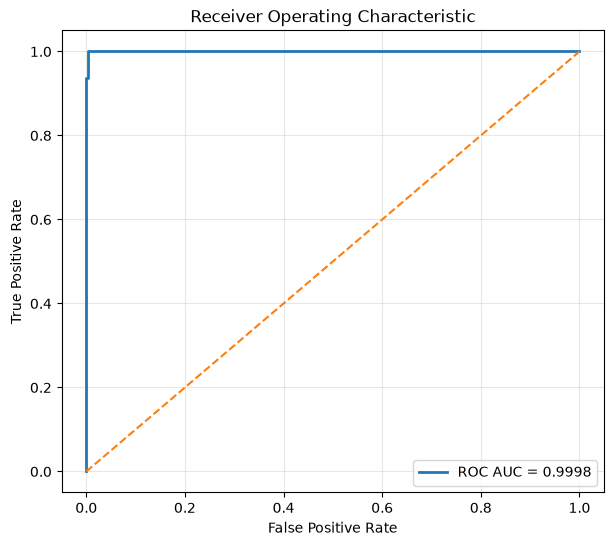

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Receiver Operating Characteristic")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

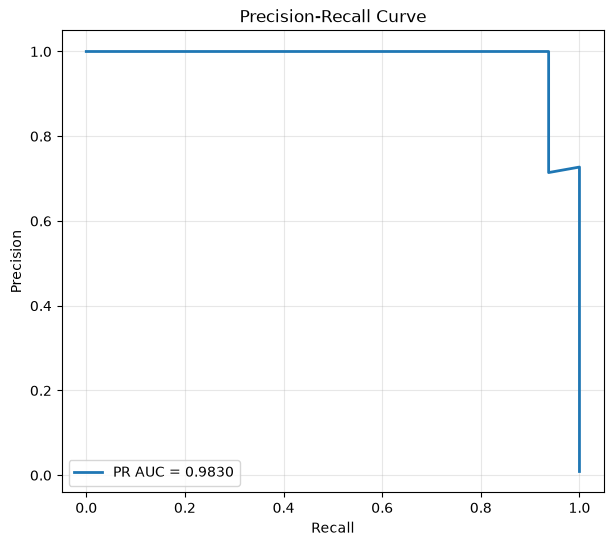

In [10]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"PR AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

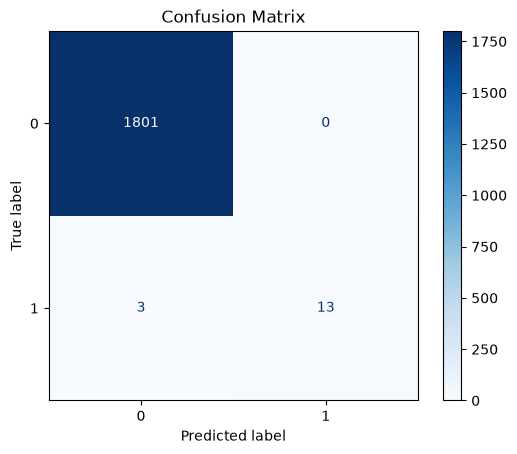

In [11]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [12]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "True Positives": tp,
        "False Positives": fp,
        "False Negatives": fn
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1 Score,True Positives,False Positives,False Negatives
0,0.10,0.789474,0.9375,0.857143,15,4,1
1,0.15,0.833333,0.9375,0.882353,15,3,1
2,0.20,0.937500,0.9375,0.937500,15,1,1
3,0.25,0.937500,0.9375,0.937500,15,1,1
4,0.30,1.000000,0.9375,0.967742,15,0,1
5,0.35,1.000000,0.9375,0.967742,15,0,1
6,0.40,1.000000,0.8750,0.933333,14,0,2
7,0.45,1.000000,0.8125,0.896552,13,0,3
8,0.50,1.000000,0.8125,0.896552,13,0,3
9,0.55,1.000000,0.8125,0.896552,13,0,3


In [13]:
threshold_df = threshold_df.round(4)

threshold_df

,Threshold,Precision,Recall,F1 Score,True Positives,False Positives,False Negatives
0,0.10,0.7895,0.9375,0.8571,15,4,1
1,0.15,0.8333,0.9375,0.8824,15,3,1
2,0.20,0.9375,0.9375,0.9375,15,1,1
3,0.25,0.9375,0.9375,0.9375,15,1,1
4,0.30,1.0000,0.9375,0.9677,15,0,1
5,0.35,1.0000,0.9375,0.9677,15,0,1
6,0.40,1.0000,0.8750,0.9333,14,0,2
7,0.45,1.0000,0.8125,0.8966,13,0,3
8,0.50,1.0000,0.8125,0.8966,13,0,3
9,0.55,1.0000,0.8125,0.8966,13,0,3


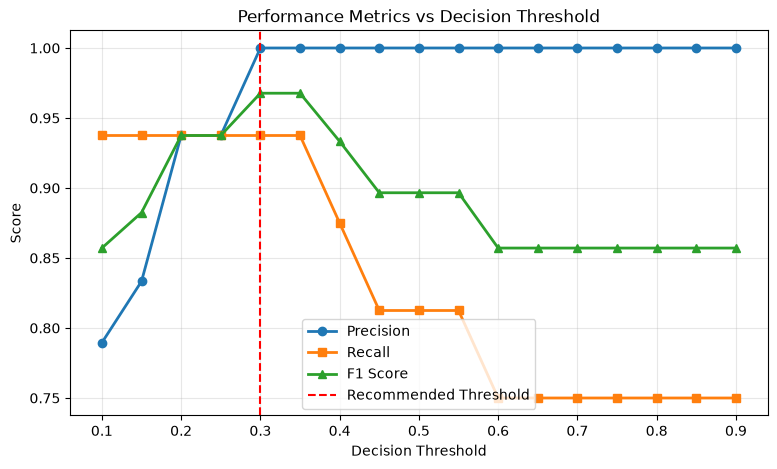

In [15]:
plt.figure(figsize=(9,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="s",
    linewidth=2,
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="^",
    linewidth=2,
    label="F1 Score"
)

plt.axvline(
    x=0.30,
    color="red",
    linestyle="--",
    label="Recommended Threshold"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Performance Metrics vs Decision Threshold")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Threshold Selection

The default classification threshold of 0.50 is not optimal for this fraud detection model.

Lowering the threshold to 0.30 improves recall from **81.25%** to **93.75%** while maintaining **100% precision**.

This allows the model to detect two additional fraudulent transactions without introducing any false positive alerts on the evaluation dataset.

For fraud detection systems, reducing false negatives is generally desirable because undetected fraud can lead to direct financial losses. Based on the current evaluation dataset, a threshold of **0.30** provides the best balance between fraud detection performance and operational efficiency.

# Business Evaluation

The tuned XGBoost model demonstrates excellent performance for fraud detection on the evaluation dataset.

### Key Findings

- ROC-AUC of **0.9998** indicates outstanding discrimination between fraudulent and legitimate transactions.
- Precision-Recall AUC of **0.9830** confirms excellent performance on this highly imbalanced dataset.
- At the default threshold (0.50), the model detects **13 out of 16** fraud cases with **no false positive alerts**.
- Threshold analysis shows that lowering the decision threshold to **0.30** improves fraud detection by identifying **15 out of 16** fraudulent transactions while maintaining **100% precision** on the evaluation dataset.

### Business Impact

In fraud detection systems, missing fraudulent transactions may result in direct financial losses, while false positives increase operational costs by requiring manual investigation.

Based on the evaluation results, a threshold of **0.30** provides a better balance between fraud detection capability and operational efficiency for this dataset.

# Deployment Considerations

Although the tuned XGBoost model achieves excellent evaluation metrics, several considerations should be addressed before production deployment.

## Strengths

- Excellent discrimination capability.
- High precision with minimal false alarms.
- Strong performance on an imbalanced fraud detection dataset.
- Suitable for assisting fraud analysts during transaction monitoring.

## Limitations

- Evaluation was performed on a limited number of fraud samples.
- Model performance should be monitored over time because fraud patterns continuously evolve.
- Periodic retraining with newly collected transaction data will be necessary.
- Threshold selection should be validated using business-specific cost analysis and operational requirements.

## Future Improvements

- Incorporate additional behavioral and temporal features.
- Perform cross-validation on larger datasets.
- Implement explainable AI techniques (SHAP) to improve transparency.
- Deploy the model as a REST API for real-time fraud scoring.

# Conclusion

The tuned XGBoost classifier achieved excellent predictive performance for fraud detection.

The evaluation demonstrated:

- High Accuracy
- Perfect Precision
- Strong Recall
- Excellent ROC-AUC
- Excellent Precision-Recall AUC

Threshold analysis further showed that selecting an appropriate decision threshold can significantly improve fraud detection performance without increasing false positive alerts on the evaluation dataset.

Overall, the tuned model is a strong candidate for fraud detection applications and provides a solid foundation for further explainability and deployment.

In [16]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC",
        "Recommended Threshold"
    ],
    "Value": [
        round(metrics["Accuracy"], 4),
        round(metrics["Precision"], 4),
        round(metrics["Recall"], 4),
        round(metrics["F1 Score"], 4),
        round(metrics["ROC AUC"], 4),
        round(metrics["PR AUC"], 4),
        0.30
    ]
})

evaluation_summary

,Metric,Value
0,Accuracy,0.9983
1,Precision,1.0000
2,Recall,0.8125
3,F1 Score,0.8966
4,ROC AUC,0.9998
5,PR AUC,0.9830
6,Recommended Threshold,0.3000


In [17]:
evaluation_summary.to_csv(
    "../reports/model_evaluation_summary.csv",
    index=False
)

print("Evaluation summary saved successfully.")

Evaluation summary saved successfully.
